In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time as time
from IPython.display import clear_output
from tqdm import trange

In [2]:
BOARD_SIZE = 5

## Environment
The environment is a simple grid-world where the player can move around.  
The reward is 1 when you reach the goal, -0.1 when you hit a wall

In [3]:
class Environment:
    def __init__(self, size=BOARD_SIZE):
        self.x = 0
        self.y = 0
        self.size = size
        self.goal_x = size - 1
        self.goal_y = size - 1

    def windX(self, action):
        return 0
    def windY(self, action):
        return 0

    def move(self, action):
        dx = 0 if action == "up" or action == "down" else 1 if action == "right" else -1
        dy = 0 if action == "left" or action == "right" else 1 if action == "up" else -1

        dx += self.windX(action)
        dy += self.windY(action)

        self.x = self.x + dx
        self.y = self.y + dy

        hit_wall = self.x < 0 or self.x >= self.size or self.y < 0 or self.y >= self.size

        self.x = min(max(0, self.x), self.size - 1)
        self.y = min(max(0, self.y), self.size - 1)

        done = self.x == self.goal_x and self.y == self.goal_y

        reward = 0 if not done else 1
        reward -= hit_wall * 0.1

        return reward, done

    def reset(self):
        self.x = 0
        self.y = 0

    def draw(self):
        fig, ax = plt.subplots()

        # Draw grid
        for i in range(self.size + 1):
            ax.plot([0, self.size], [i, i], color='black')
            ax.plot([i, i], [0, self.size], color='black')

        # Add coordinates inside the grid in the top-right corner of each cell
        for i in range(self.size):
            for j in range(self.size):
                ax.text(j + 0.95, i + 0.95, f"({j},{i})", fontsize=8, color='gray', ha='right', va='top')

        # Draw goal (circle)
        ax.add_patch(plt.Circle((self.goal_x + 0.5, self.goal_y + 0.5), 0.3, color='red', label="Goal"))

        # Draw player (circle)
        ax.add_patch(plt.Circle((self.x + 0.5, self.y + 0.5), 0.3, color='blue', label="Player"))


        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')

        plt.show()

class SymmetricWindEnvironment(Environment):
    def __init__(self, size=BOARD_SIZE, prob=0.9):
        super().__init__(size)
        self.prob=prob

    def windX(self, action):
        if action in ["left", "right"]:
            return 0
        if np.random.rand() < self.prob:
            return np.random.choice([-1, 1])
        return 0
    def windY(self, action):
        if action in ["up", "down"]:
            return 0
        if np.random.rand() < self.prob:
            return np.random.choice([-1, 1])
        return 0

class AsymmetricWindEnvironment(Environment):
    def __init__(self, size=BOARD_SIZE, prob=0.9):
        super().__init__(size)
        self.prob=prob

    def windX(self, action):
        if action in ["left", "right"]:
            return 0
        if np.random.rand() < self.prob:
            return np.random.choice([-2, -1, 1])
        return 0
    def windY(self, action):
        if action in ["up", "down"]:
            return 0
        if np.random.rand() < self.prob:
            return np.random.choice([-2, -1, 1])
        return 0


## Value functions
Today we will only deal with prediction, thus the problem of estimating how good a policy is (its value function)  
For this, we will use both first visit and every visit MC

In [4]:
class Value:
    def __init__(self, size=BOARD_SIZE, gamma=0.9, alpha=0.1):
        self.values = np.zeros((size, size))
        self.counts = np.zeros((size, size))
        self.gamma = gamma
        self.alpha = alpha
        self.size = size
    def update(self, trajectory, rewards):
        raise NotImplementedError()

    def draw(self):
        fig, ax = plt.subplots()
        # Create a color map based on the value grid
        cax = ax.imshow(self.values, cmap='coolwarm', origin='lower', extent=[0, self.size, 0, self.size])

        # Add a color bar to indicate value levels
        fig.colorbar(cax)

        # Draw grid lines
        for i in range(self.size + 1):
            ax.plot([0, self.size], [i, i], color='black', lw=0.5)
            ax.plot([i, i], [0, self.size], color='black', lw=0.5)

        # Add coordinates and values inside the grid in the top-right corner of each cell
        for i in range(self.size):
            for j in range(self.size):
                ax.text(j + 0.9, i + 0.9, f"({j},{i})", fontsize=8, color='gray', ha='right', va='top')
                # Optionally display the value itself at the center of the cell
                ax.text(j + 0.5, i + 0.5, f"{self.values[i,j]:.2f}", fontsize=8, color='black', ha='center', va='center')

        # Set limits and grid settings
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')

        plt.show()


class ValueEveryVisit(Value):
    def update(self, trajectory, rewards):
        returns = 0
        trajectory = trajectory[::-1]
        rewards = rewards[::-1]
        for i in range(len(trajectory)):
            returns = self.gamma * returns + rewards[i]
            x, y = trajectory[i]
            self.values[y, x] = (self.values[y, x] * self.counts[y,x] + returns) / (self.counts[y,x] + 1)
            self.counts[y,x] += 1

class ValueFirstVisit(Value):
    def update(self, trajectory, rewards):
        returns = 0
        trajectory = trajectory[::-1]
        rewards = rewards[::-1]
        for i in range(len(trajectory)):
            # Check if the state has been visited before
            tmp = False
            for el in trajectory[i+1:]:
                if np.equal(el, trajectory[i]).all():
                    tmp=True
                    break

            returns = self.gamma * returns + rewards[i]

            if tmp:
              continue

            x, y = trajectory[i]
            self.values[y, x] = (self.values[y, x] * self.counts[y,x] + returns) / (self.counts[y,x] + 1)
            self.counts[y,x] += 1

## Policy
Since we are doing prediction, we get to decide the policy a priori, instead of learning it

In [6]:
class Policy:
    def __init__(self, size=BOARD_SIZE):
        self.size=size
    def act(self, x, y):
        raise NotImplementedError()
class LPolicy(Policy):      # all ups and then all right
    def act(self, x, y):
        # if x < self.size-1:
        #     return "right"
        # return "up"
        if y < self.size-1:
            return "up"
        return "right"
class RandomPolicy(Policy):
    def act(self, x, y):
        return np.random.choice(["up", "down", "left", "right"])

## Simulation

In [7]:
env = SymmetricWindEnvironment(prob=0.9)

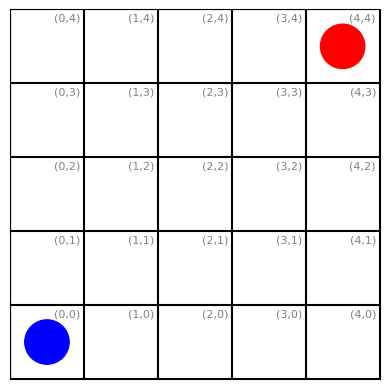

In [8]:
env.draw()

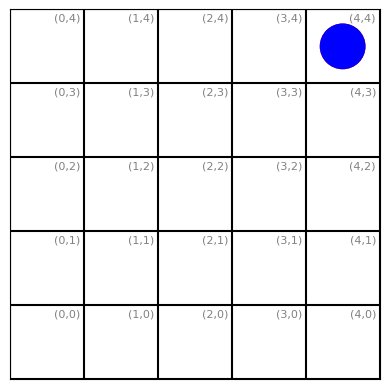

In [15]:
env = SymmetricWindEnvironment(prob=0.9)
policy = LPolicy()
while True:
    x, y = env.x, env.y
    action = policy.act(x, y)
    reward, done = env.move(action)
    clear_output(wait=True)
    env.draw()
    time.sleep(3)
    if done:
        break

## MC prediction

### Every visit MC prediction

In [21]:
env = AsymmetricWindEnvironment()
policy = RandomPolicy()
value = ValueEveryVisit()
EPOCHS = 1000

In [22]:
for _ in trange(EPOCHS):
    trajectory = []
    rewards = []
    while True:
        x, y = env.x, env.y
        trajectory.append((x, y))
        action = policy.act(x, y)
        reward, done = env.move(action)
        rewards.append(reward)
        if done:
            env.reset()
            break
    value.update(trajectory, rewards)

100%|██████████| 1000/1000 [00:15<00:00, 64.08it/s]


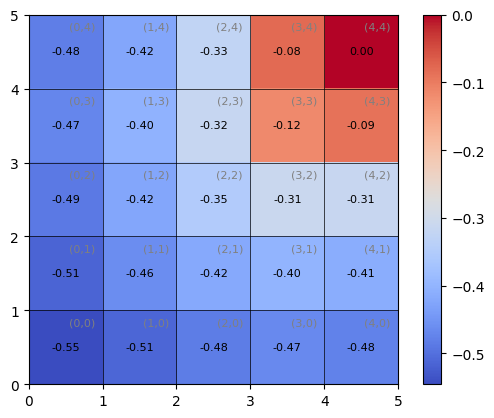

In [23]:
value.draw()

### First visit MC prediction

In [24]:
env = AsymmetricWindEnvironment()
policy = RandomPolicy()
value = ValueFirstVisit()
EPOCHS = 1000

In [25]:
for _ in trange(EPOCHS):
    trajectory = []
    rewards = []
    while True:
        x, y = env.x, env.y
        trajectory.append((x, y))
        action = policy.act(x, y)
        reward, done = env.move(action)
        rewards.append(reward)
        if done:
            env.reset()
            break
    value.update(trajectory, rewards)

100%|██████████| 1000/1000 [00:47<00:00, 20.95it/s]


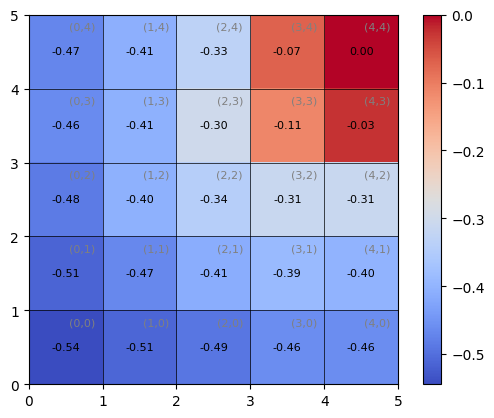

In [26]:
value.draw()

First visit is slower (even if it is more accurate), and the two estimated values are quite the same (at least proportional, so same in order).

## Competition

In [27]:
class CompetitionEnvironment(Environment):
    def __init__(self, size=BOARD_SIZE, prob=0.9):
        super().__init__(size)
        self.prob=prob

    def windX(self, action):
        return {
            0: {
                0: np.random.choice([-2, -1, 1]),
                1: 0
            },
            1: {
                1: np.random.choice([-1, 1, 2]),
                0: 0
            }
        }[self.y%2][self.x%2]

    def windY(self, action):
        return {
            0: {
                1: np.random.choice([-2, -1, 1]),
                0: 0
            },
            1: {
                0: np.random.choice([-1, 1, 2]),
                1: 0
            }
        }[self.x%2][self.y%2]

In [56]:
env = CompetitionEnvironment()
policy = LPolicy()
value = ValueEveryVisit()
EPOCHS = 10000

In [50]:
for _ in trange(EPOCHS):
    trajectory = []
    rewards = []
    while True:
        x, y = env.x, env.y
        trajectory.append((x, y))
        action = policy.act(x, y)
        reward, done = env.move(action)
        rewards.append(reward)
        if done:
            env.reset()
            break
    value.update(trajectory, rewards)

100%|██████████| 10000/10000 [00:09<00:00, 1103.64it/s]


In [51]:
# BENCHMARK : LPolicy
value.values[0][0]

np.float64(0.16604921312487916)

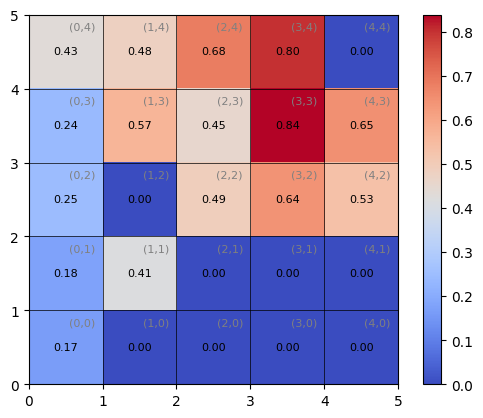

In [52]:
value.draw()

In [73]:
class CompetitionPolicy(Policy):
    def act(self, x, y):
        # x: x coordinate of the agent
        # y: y coordinate of the agent
        # return "up" or "down" or "left" or "right"
        if x == 4: return "up"   # On the far right, just go up
        if y == 4: return "right" # On the top, just go right
        if y %2 == 0:
            return "up"
        else:
          return "right"

In [74]:
env = CompetitionEnvironment()
policy = CompetitionPolicy()
value = ValueEveryVisit()
EPOCHS = 10000

In [75]:
for _ in trange(EPOCHS):
    trajectory = []
    rewards = []
    while True:
        x, y = env.x, env.y
        trajectory.append((x, y))
        action = policy.act(x, y)
        reward, done = env.move(action)
        rewards.append(reward)
        if done:
            env.reset()
            break
    value.update(trajectory, rewards)

100%|██████████| 10000/10000 [00:08<00:00, 1193.52it/s]


In [76]:
# my competition Policy
value.values[0][0]

np.float64(0.18619307529135626)

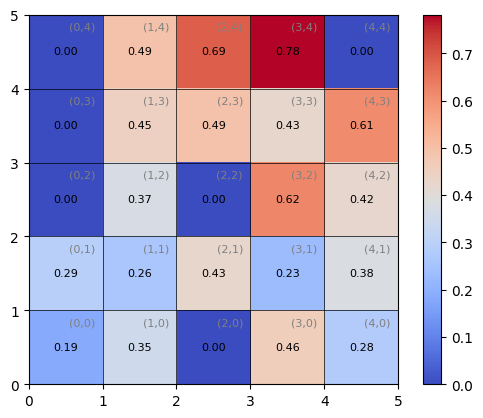

In [77]:
value.draw()